# B03 · PFN and the TabPFN generations

Portable offline notebook: Python + NumPy. The embedded packet contains raw author diagnostic predictions and authenticated upstream archives. This execution replays evidence; it does not run new TabPFN inference or dispatch the incomplete benchmark. Three live TODOs plus a written defense remain learner work.

In [1]:
import base64,hashlib,io,itertools,json,math,tempfile,zipfile
from pathlib import Path
import numpy as np
workspace=Path(tempfile.mkdtemp(prefix="b03-notebook-"))

# PFN and the TabPFN generations

<p class="eyebrow">B03 · Year 5 → 6 bridge · 25-minute core + notebook investigation</p>

**Your win:** trace how a fixed pretrained model learns from support rows, then decide exactly which version, inference recipe and evidence support a claim.

[B02](https://avistian.github.io/relational/lessons/b02-numerical-embeddings-and-ensembles.html) separated numerical representation from ensemble computation. It left a question: must every member learn new weights on your table? A PFN moves much of that learning into pretraining across tasks. At inference, the support table changes the prediction even when model weights stay fixed. For our relational mission, this matters because a flat-table foundation model is a serious baseline—but a strong flat-table result does not establish relational reasoning.

Prerequisites: conditional probability, weighted averages, attention's query/key/value roles; review [L061](https://avistian.github.io/relational/lessons/0061-prior-data-fitted-networks.html), [L062](https://avistian.github.io/relational/lessons/0062-tabpfn-v1.html) and [L064](https://avistian.github.io/relational/lessons/0064-tabpfn-v2.html) if needed. B02 author preparation is not evidence that you have mastered it.

## 1. Learn an inference rule before meeting this table

Imagine two hypotheses for a coin: H₁ has success probability .25, H₂ has probability .75. Give each prior weight .5. Three observed successes have likelihoods .25³ and .75³. Multiplying by the prior and normalizing gives posterior weights **1/28 and 27/28**. The next-success prediction is `(1/28)×.25 + (27/28)×.75 = 41/56 ≈ .73214`. The hypothesis definitions did not change; the support evidence changed their weights.

This finite calculation is an exact Bayesian teaching oracle, not TabPFN's actual prior. PFNs approximate a related posterior-predictive mapping with a neural network trained on many sampled tasks. A task generator produces features and targets; training hides query targets from the input and minimizes query prediction loss. Once θ is learned, the model computes `pθ(y_query | x_query, support)` without requiring task-specific gradient updates. Approximation error and mismatch between synthetic and real tasks remain possible. [PFN paper](https://arxiv.org/abs/2112.10510) · [TabPFN v1, §§2–3](https://arxiv.org/abs/2207.01848).

**Trace it:** With no observations, the finite model predicts .5. With three failures, it predicts 15/56. More support need not push confidence in the same direction. In the notebook, implement the normalization rather than calling a classifier API.

Recall L061: support changes the conditional prediction without redefining the prior.

## 2. Model architecture: follow one prediction

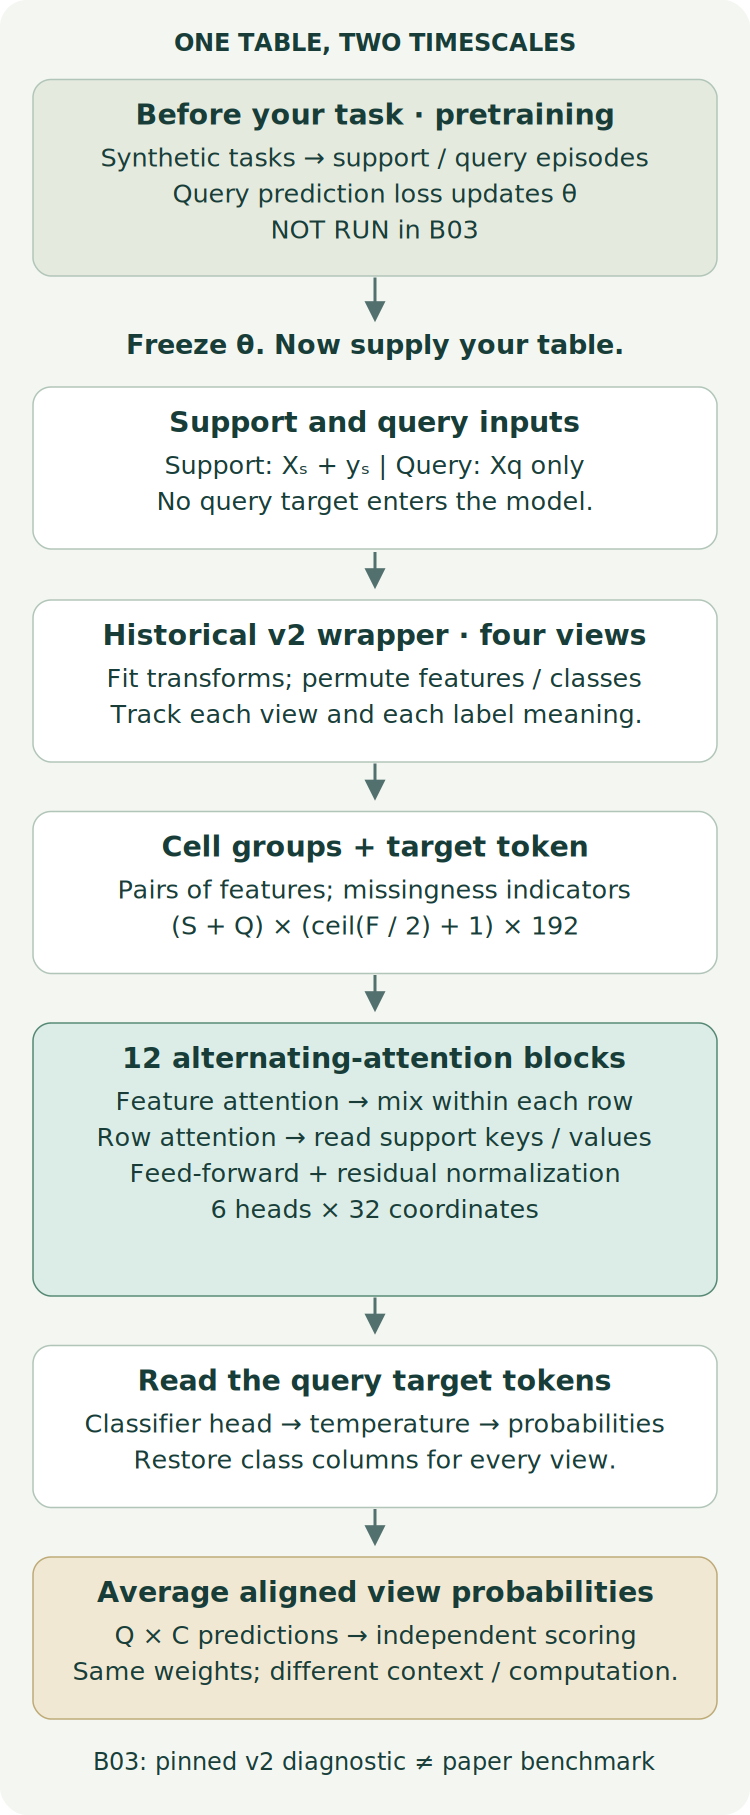

The diagram makes the historical v2 path concrete. With S support rows, Q queries and F features, group pairs of feature values into G = ceil(F/2) groups and append a target token. The hidden table has shape `(S+Q) × (G+1) × 192` (omitting batch). In each of 12 blocks, feature attention mixes information inside each row; row attention transfers support information across rows; a feed-forward transformation refines the representation. Six attention heads each have width 32. Query labels are unavailable. Query tokens attend to support keys/values in the historical model, while wrapper preprocessing must be audited separately. The query target representation feeds class logits. [Visible L064 implementation](https://avistian.github.io/relational/labs/relkit/tabpfn_l064_v2.py) · [Nature paper, architecture and inference Methods](https://www.nature.com/articles/s41586-024-08328-6).

A wrapper adds important work: fitting transformations, choosing feature/class permutations, applying temperature, restoring class meanings and averaging views. Four views of one checkpoint are four computations, not four independently pretrained models. The notebook includes the complete L064 educational model for inspection and the pinned original-release diagnostic driver. The new learner work targets posterior weighting, output alignment and contract matching; it does not reimplement every generation.

**What stays fixed?** In base ICL, θ stays fixed; context representations, caches and predictions change. Optional fine-tuning changes θ. B02's validation-selected ensemble changes which predictors are combined. These are different adaptation mechanisms. A cache is derived state, not evidence of new pretraining.

## 3. Generations change the contract

Read the matrix as **reported operating envelopes and access distinctions**, not measured B03 capacities or guaranteed hard limits. Only historical v2 is executed here, in a course diagnostic. Match the exact release before transferring any claim.

| Version / variant | Inputs and reported scale | Mechanism / missingness | Access boundary | Evaluation / computation contract |
|---|---|---|---|---|
| [v1](https://arxiv.org/abs/2207.01848) | Numeric classification; ≤10 classes; 1k support rows / 100 features | Row tokens; no dedicated missingness channel | Released weights / inference | 18-task numeric benchmark; 5 resamples; typically 32 views |
| [v2](https://www.nature.com/articles/s41586-024-08328-6) | Numeric + categorical; classification (≤10 classes) / regression; 10k / 500 | Grouped cells; explicit missingness signals | Released weights; historical license | Nature: 10 repetitions; default 4 classifier / 8 regressor views; tuning separate |
| [2.5](https://arxiv.org/html/2511.08667v1) | 50k design; evaluated to 100k / 2k features | Deeper alternating attention; 3-feature groups; 64 learned rows; inherited missingness encoding | Released weights with separate terms; API | TabArena and additional tasks; base / fine-tuned / ensemble differ; exact run recipe NOT_AUTHENTICATED here |
| [2.6](https://arxiv.org/html/2609.17895v2) | Later interim release; summary lists 100k / 2k | Do not infer recipe from the 2.5 name | Release-specific weights / access | Inventory only: B03 does not authenticate a distinct 2.6 benchmark recipe |
| [3 base](https://arxiv.org/html/2605.13986v2) | Up to 1M rows / 2k features in report summary | Scaling, small cache, many-class decoder; missingness indicators | Released weights with separate terms; API | TabArena / TALENT; exact estimator count and split recipe NOT_AUTHENTICATED here |
| [3.5 base / Fast](https://arxiv.org/html/2609.17895v2) | Current release: up to 1M rows / 20k features; not a B03 measurement | Fourier + support ECDF and missingness signals; shared classification/regression checkpoint per variant | Base/Fast weights; separate weight terms | Report: base 8 views, Fast 4; exact benchmark recipe NOT_AUTHENTICATED here |
| [3 / 3.5 Plus, Thinking](https://arxiv.org/html/2609.17895v2) | Expanded system capabilities; version-specific modalities | Additional preprocessing / test-time computation; unreleased details stay unknown | Hosted offerings; base weights do not reproduce system | Pin API model, mode, time/selection budget; do not transfer headline scores to base |


The lineage is causal. V1 compresses each row into a token; v2 preserves more feature structure through alternating attention. The 2.5 report deepens this design, groups three features and adds 64 learned extra rows. Those learned rows are not the later API's Thinking mode. V3 adds scaling and many-class machinery. V3.5 moves more numerical representation into its cell encoder through Fourier and support-distribution features; its report removes earlier quantile/SVD wrapper transforms and uses eight base estimators versus four Fast estimators. This reconnects to B02: representation and ensembling still both matter. [2.5 §3](https://arxiv.org/html/2511.08667v1) · [3 §2](https://arxiv.org/html/2605.13986v2) · [3.5 §3](https://arxiv.org/html/2609.17895v2).

The 2.5 report describes a 50k-row design while also evaluating up to 100k. Later summary tables list 100k. Keep intended design, evaluated range and current package guardrails separate. Similarly, accepting NaNs does not establish robustness when missingness changes between support and queries. B18a will test that shift explicitly.

**Access is part of reproducibility.** Distinguish downloadable code, weights and a hosted service. For later versions, consult each linked weight license separately from the package license; do not inherit v2 permissions. Availability of inference weights does not supply the full synthetic generator or training history. Plus and Thinking include additional inference behavior; do not invent unpublished internals. [Official release and access documentation](https://github.com/PriorLabs/TabPFN/blob/15f5e6b2b629b905879b9be907261416f20d0df5/README.md).

## 4. Test a symmetry, not just an accuracy

Class names are arbitrary. Let π map each original label to a new label. Run the same model with support labels π(y), then restore the prediction columns: **aligned[:,c] = remapped[:,π(c)]**. An equivariant predictor should agree with its original probabilities up to the declared numerical tolerance. This is a property to test, not a promise conferred by attention. [EquiTabPFN, target-permutation formulation](https://arxiv.org/html/2502.06684v4).

For π=[2,0,1], a new-order probability vector `[.2,.1,.7]` becomes `[.7,.2,.1]` in the old class order. Using the inverse permutation here is a common mistake; a binary swap cannot detect it because it is its own inverse. Use a three-cycle.

**Portable interaction:** run the saved permutation panel below using your live alignment function.

**Measured:** maximum aligned change **0.071617**; accuracy **94.67%** for every permutation. All five nonidentity maps exceed tolerance. Repeated identical-query prediction changes by **0**. The independent audit reconciles all **450** probability rows. [Raw evidence](https://avistian.github.io/relational/labs/evidence/b03/permutation-diagnostic.json) · [Scalar audit](https://avistian.github.io/relational/labs/evidence/b03/diagnostic-audit.json).

The fixed diagnostic is sklearn Iris, all 150 rows,75 support / 75 query, stratified split seed 0, model seed 0, pinned v2 classifier, four views and CPU float32. We test all six label permutations with atol 1e-6 and rtol 0, chosen before execution. There is no class-cap workaround: this task has only three classes. All 450 probability rows and the 75-row repeat are retained. This is fresh pretrained inference, **not** fresh pretraining, a reproduction of EquiTabPFN, or a paper benchmark result. A single fixture supplies a counterexample; it does not estimate how often this happens.

A separate repeat after changing an unused copy of the scoring labels returned identical predictions. It confirms this worker passes query features only. It does not prove query-feature independence: L064 found historical preprocessing counterexamples where adding another query changes an existing prediction. Label isolation and query-batch independence are different tests.

## 5. The full-reproduction gate is part of the result

**B03-TABPFNV2-BLOOD-OFFICIAL-SPLITS: INCOMPLETE_SOURCE_PROTOCOL.** The approved target was default historical v2 on blood-transfusion across all ten official benchmark splits. The archived evaluation script imports a missing dataset loader. Its helpers disagree on split defaults; multiple OpenML tasks describe the same dataset. We cannot authenticate the exact paper split/configuration/checkpoint mapping or per-split reference. [Source gate](https://avistian.github.io/relational/labs/evidence/b03/source-gate.json) · [Archive record](https://zenodo.org/records/13981285) · [Reproduction protocol](https://avistian.github.io/relational/labs/b03-reproduction.md).

Consequently **zero benchmark runs** were dispatched. The Iris diagnostic does not fill the missing benchmark cell. The executable preflight refuses `--run`; archived source is preserved for recovery. Full original pretraining, all-dataset evaluation, tuned competitors and later-generation runs remain NOT_RUN. USD0 cloud/API spent; the approved ceiling is USD10 total, with USD2 reserved for overhead. Local numerical attempts are recorded separately under a 3600-second ceiling.

To unblock, recover the original loader and roster, authenticate all ten ordered row partitions and the complete inference configuration, link the checkpoint and numeric reference, then forecast the full run cost. Choosing a plausible modern default would answer a different question.

## 6. Practice, defend and revisit

[Open the student notebook](https://avistian.github.io/relational/labs/b03-pfn-tabpfn-generations.ipynb) · [Executed author solution](https://avistian.github.io/relational/labs/html/b03-pfn-tabpfn-generations.html) · [Field guide](https://avistian.github.io/relational/reference/b03-pfn-contracts.html) · [Portable reproducer](https://avistian.github.io/relational/labs/evidence/b03/reproducer.zip).

1. **TODO:** implement finite-prior posterior prediction. CHECK: three successes yield 41/56; an impossible support event must fail explicitly.
2. **TODO:** restore probability-column meanings. CHECK: a three-cycle and every saved diagnostic row agree with an independent scalar oracle.
3. **TODO:** compare complete version/variant/checkpoint/recipe/data/split/budget contracts. CHECK: unknown fields yield INCOMPLETE; a known mismatch yields INCOMPARABLE. Matching is necessary, not proof of reproduced scores.
4. **EXIT:** explain fixed θ versus changed context; draw the historical v2 input-to-output path; interpret unchanged accuracy with changed probabilities; specify two falsification tests; name exactly what would unblock the benchmark. State why a base result cannot substantiate a Thinking claim.

For practical comparisons, propose a tuned tree and a strong MLP, with common row identities and disclosed tuning/inference budgets. A v2-vs-v3.5 score difference would change several components at once; it is not an isolated architecture ablation. No such baseline fits are newly run in B03.

**Primary reading:** [TabPFN-3.5 v2, §§3–4](https://arxiv.org/html/2609.17895v2), followed by the historical v2 architecture Methods. Highlight which statements concern the base checkpoint versus the surrounding system. After completion, revisit in 1, 7 and 30 days: reconstruct the posterior example, align a new three-cycle, and audit a new model claim without looking at this matrix.

Ask the agent to check your trace or challenge your written defense. Author checks leave learner status **PENDING_WRITTEN_DEFENSE**. Next, [B04](https://avistian.github.io/relational/plan/year-5-6-bridge.md#b04) asks how TabICL compresses feature information before dataset-level attention; carry the same support/query and compute contract into that comparison.

Built with TabPFN. Historical v2 attribution and license: [archived release](https://zenodo.org/records/13981285).


In [2]:
payload=base64.b64decode('...')
assert hashlib.sha256(payload).hexdigest()=='f609b0a0c59409f236e31a321196efecaab14b385b0e65c029d91a40bf2299f3'
with zipfile.ZipFile(io.BytesIO(payload)) as z:z.extractall(workspace)
evidence=workspace/"labs/evidence/b03"
raw=json.loads((evidence/"permutation-diagnostic.json").read_text())

## SOLUTION · posterior_predictive

Validate finite probabilities and weights; normalize prior × likelihood, then average query probabilities. Reject impossible support. Why does multiplying every likelihood by 10 leave the prediction fixed?

In [3]:
def posterior_predictive(prior, likelihood, query_prob):
    """Exact finite-prior Bayesian prediction, not a trained neural approximation."""
    p,l,q=[np.asarray(x,dtype=float) for x in (prior,likelihood,query_prob)]
    if p.ndim!=1 or not len(p) or p.shape!=l.shape or p.shape!=q.shape:
        raise ValueError('Three equal nonempty vectors required')
    if not all(np.isfinite(x).all() for x in (p,l,q)) or np.any(p<0) or np.any(l<0) or np.any((q<0)|(q>1)):
        raise ValueError('Finite nonnegative weights and probabilities required')
    if not np.isclose(p.sum(),1) or l.max()<=0:raise ValueError('Normalized prior and nonzero likelihood required')
    weights=p*(l/l.max())
    if weights.sum()<=0:raise ValueError('Support impossible under prior')
    return float((weights/weights.sum())@q)

## SOLUTION · align_probabilities

Map each old column c to its new-label column π(c). Preserve row identities and reject non-bijections. Predict the three-cycle result before executing.

In [4]:
def align_probabilities(probabilities, old_to_new):
    """If labels transform c -> pi[c], restore old column c from new pi[c]."""
    p=np.asarray(probabilities,dtype=float);pi=np.asarray(old_to_new)
    if p.ndim!=2 or not p.shape[0] or pi.ndim!=1 or pi.dtype.kind not in 'iu' or len(pi)!=p.shape[1]:
        raise ValueError('Probability matrix and integer class permutation required')
    if not np.array_equal(np.sort(pi),np.arange(len(pi))):raise ValueError('Not a bijection')
    if not np.isfinite(p).all() or np.any(p<0) or np.any(p>1) or not np.allclose(p.sum(1),1,atol=1e-6,rtol=0):
        raise ValueError('Invalid probability rows')
    return p[:,pi].copy()

## SOLUTION · compare_variants

Check all seven contract fields. Missing/unknown → INCOMPLETE; any known difference → INCOMPARABLE; complete match → MATCHED_CONTRACT. Do not interpret matching as reproduced scores.

In [5]:
def compare_variants(measured, claimed):
    """A matched contract is necessary, not sufficient, for score reproduction."""
    keys=('version','variant','checkpoint','recipe','data','splits','budget')
    if any(not isinstance(x.get(k),str) or x[k] in ('','UNKNOWN','NOT_RUN') for x in (measured,claimed) for k in keys):
        return 'INCOMPLETE'
    return 'MATCHED_CONTRACT' if all(measured[k]==claimed[k] for k in keys) else 'INCOMPARABLE'

## CHECK · behavioral feedback on your functions

In [6]:
def check_functions(posterior_predictive,align_probabilities,compare_variants):
    # Two latent hypotheses: three successes update [1/2,1/2] to [1/28,27/28].
    p=np.array([.5,.5]);l=np.array([.25**3,.75**3]);q=np.array([.25,.75])
    assert abs(posterior_predictive(p,l,q)-41/56)<1e-12
    assert posterior_predictive(p,np.ones(2),q)==.5
    assert abs(posterior_predictive(p,10*l,q)-41/56)<1e-12
    assert posterior_predictive([1,0],[1,1],[.2,.9])==.2
    # An asymmetric 3-cycle detects the common inverse-permutation mistake.
    x=np.array([[.2,.1,.7],[.6,.3,.1]])
    assert np.allclose(align_probabilities(x,[2,0,1]),[[.7,.2,.1],[.1,.6,.3]])
    assert np.array_equal(x,[[.2,.1,.7],[.6,.3,.1]])
    contract=dict(version='2',variant='base',checkpoint='sha',recipe='four-view',data='blood',splits='official',budget='fixed')
    assert compare_variants(contract,dict(contract))=='MATCHED_CONTRACT'
    for key in contract:
        other=dict(contract);other[key]='different'
        assert compare_variants(contract,other)=='INCOMPARABLE'
        other=dict(contract);other[key]=None
        assert compare_variants(contract,other)=='INCOMPLETE'
    assert compare_variants({}, {})=='INCOMPLETE'
    cases=[(posterior_predictive,([.5,.5],[0,0],[.2,.8])),
           (posterior_predictive,([1,-1],[1,1],[.2,.8])),
           (posterior_predictive,([1],[float('nan')],[.2])),
           (posterior_predictive,([1],[1],[1.1])),
           (align_probabilities,(x,[0,0,2])),
           (align_probabilities,(x,[0,1])),
           (align_probabilities,([[.1,.1,.1]],[0,1,2]))]
    for fn,args in cases:
        try:fn(*args)
        except ValueError:pass
        else:raise AssertionError('Invalid evidence accepted')
    return dict(status='PASS',posterior='41/56',three_cycle_alignment='PASS',invalid_inputs_rejected=len(cases),contract_fields_checked=len(contract))

In [7]:
print(check_functions(posterior_predictive,align_probabilities,compare_variants))

{'status': 'PASS', 'posterior': '41/56', 'three_cycle_alignment': 'PASS', 'invalid_inputs_rejected': 7, 'contract_fields_checked': 7}


## PROVIDED · independent scalar evidence and archive audit

This code does not import your functions. It authenticates both archive hashes, checks the absent upstream loader, verifies complete permutation coverage and row identities, and recomputes diagnostic metrics. Expected report identities are frozen in the embedded packet.

In [8]:
"""Independent source gate and diagnostic evidence audit; standard library only."""
import hashlib,itertools,json,math,zipfile
from pathlib import Path

ARCHIVES={'TabPFN-main.zip':'936f4a9433bb89ec660dd0343ed5dca61c842ae9c60e271dc82c87a3a99a2db5','TabPFN-original-stale.zip':'0a995999b235d47eba66488c42cd565d7646008589ba1693af94f167dd4cd80a'}

def audit_sources(root):
    root=Path(root);names={}
    for name,digest in ARCHIVES.items():
        b=(root/name).read_bytes()
        if hashlib.sha256(b).hexdigest()!=digest:raise ValueError('Archive identity changed: '+name)
        with zipfile.ZipFile(root/name) as z:
            names[name]=z.namelist()
            if name=='TabPFN-original-stale.zip':
                prefix='TabPFN-Release-main/'
                source=z.read(prefix+'tabpfn/scripts/tabular_evaluation.py').decode()
                assert 'from tabpfn.datasets import' in source
                assert not any(n.startswith(prefix+'tabpfn/datasets') for n in z.namelist())
                assert 'N_SPLITS = 5' in source
                helper=z.read(prefix+'tabpfn/scripts/tabular_evaluation_notebook_utils.py').decode()
                assert 'range(0, 10)' in helper
    return dict(status='INCOMPLETE_SOURCE_PROTOCOL',experiment='B03-TABPFNV2-BLOOD-OFFICIAL-SPLITS',archives=ARCHIVES,missing_loader='tabpfn.datasets',benchmark_runs=0,
        gaps=['Paper-to-OpenML task and ten ordered split identities not authenticated','Archived evaluation imports an absent dataset loader','Historical experiment configuration and checkpoint linkage not authenticated','Per-split reference predictions or exact numeric target not recovered'],
        observations=['Archive helper defaults disagree: five versus ten splits','Multiple OpenML tasks use dataset 1464; same dataset is not same split'],
        fresh_benchmark='NOT_RUN',pretraining='NOT_RUN',full_benchmark='NOT_RUN',cloud_usd=0)

def audit_predictions(record):
    expected={'data':'d88c5d9a92842376c4d766aca0aad26d5990c781a168200443aecbcee2cb4228','labels':'76bbcf80f5bd04bba239fb42dd5b607981b67533a20aac705d2b945eee06df3b','train_ids':'b076716bdb9b38e672f31844b9f2d688fbfe08951077c33240a67f6aadb0f167','test_ids':'fbb83398fe16cbc895e927025afed751b2ddb95be8add1ca0d028456a9488287'}
    for key,digest in expected.items():
        assert hashlib.sha256(json.dumps(record[key],separators=(',',':')).encode()).hexdigest()==digest,key
    assert record['checkpoint_sha256']=='f65a35685aeef42e31b796d9bfa34e68d6fc780bc98e7bff7763802964cf435f'
    assert record['n_estimators']==4 and record['split_seed']==record['model_seed']==0
    assert record['precision']=='CPU float32' and record['tolerance']==dict(atol=1e-6,rtol=0)
    assert record['versions']['tabpfn']=='2.0.9' and record['versions']['sklearn']=='1.6.1'
    rows=record['records'];assert [tuple(x['permutation']) for x in rows]==list(itertools.permutations(range(3)))
    base=rows[0]['probabilities'];n=len(record['test_ids']);targets=[record['labels'][i] for i in record['test_ids']]
    output=[]
    for row in rows:
        p=row['probabilities'];pi=row['permutation'];assert len(p)==n
        for v in p:
            assert len(v)==3 and all(math.isfinite(a) and 0<=a<=1 for a in v)
            assert abs(math.fsum(v)-1)<1e-6
        aligned=[[v[pi[c]] for c in range(3)] for v in p]
        delta=max(abs(aligned[i][c]-base[i][c]) for i in range(n) for c in range(3))
        nll=-math.fsum(math.log(max(aligned[i][targets[i]],1e-15)) for i in range(n))/n
        accuracy=sum(max(range(3),key=lambda c:aligned[i][c])==targets[i] for i in range(n))/n
        output.append(dict(permutation=pi,max_abs_delta=delta,within_tolerance=delta<=1e-6,accuracy=accuracy,log_loss=nll))
    repeat=rows[0]['repeat_probabilities'];assert len(repeat)==n and all(len(v)==3 for v in repeat)
    assert all(math.isfinite(a) for v in repeat for a in v)
    repeat_delta=max(abs(repeat[i][c]-base[i][c]) for i in range(n) for c in range(3))
    assert repeat_delta<=1e-6
    return dict(status='PASS',evidence='COMPLETE_COURSE_DIAGNOSTIC',permutations=6,prediction_rows=6*n,rows=output,max_abs_delta=max(r['max_abs_delta'] for r in output),repeat_max_abs_delta=repeat_delta,
        conclusion='Observed permutation sensitivity' if any(not r['within_tolerance'] for r in output) else 'Within tolerance on this fixture only',
        benchmark='NOT_RUN',equivariant_model_training='NOT_RUN',query_feature_independence='NOT_ESTABLISHED')


In [9]:
report={'source':audit_sources(workspace/'labs/sources/b03'),'diagnostic':audit_predictions(raw)}
assert report['source']==json.loads((evidence/'source-gate.json').read_text())
assert report['diagnostic']==json.loads((evidence/'diagnostic-audit.json').read_text())
Path('b03-report.json').write_text(json.dumps(report,indent=2)+'\n')
print(json.dumps(report,indent=2))

{
  "source": {
    "status": "INCOMPLETE_SOURCE_PROTOCOL",
    "experiment": "B03-TABPFNV2-BLOOD-OFFICIAL-SPLITS",
    "archives": {
      "TabPFN-main.zip": "936f4a9433bb89ec660dd0343ed5dca61c842ae9c60e271dc82c87a3a99a2db5",
      "TabPFN-original-stale.zip": "0a995999b235d47eba66488c42cd565d7646008589ba1693af94f167dd4cd80a"
    },
    "missing_loader": "tabpfn.datasets",
    "benchmark_runs": 0,
    "gaps": [
      "Paper-to-OpenML task and ten ordered split identities not authenticated",
      "Archived evaluation imports an absent dataset loader",
      "Historical experiment configuration and checkpoint linkage not authenticated",
      "Per-split reference predictions or exact numeric target not recovered"
    ],
    "observations": [
      "Archive helper defaults disagree: five versus ten splits",
      "Multiple OpenML tasks use dataset 1464; same dataset is not same split"
    ],
    "fresh_benchmark": "NOT_RUN",
    "pretraining": "NOT_RUN",
    "full_benchmark": "NOT_RUN",

## APPLY · your alignment controls every saved prediction

The author generated fresh predictions; you now replay them. For each map, use your function to restore class semantics and compare its errors with the independent scalar oracle. Never replace a failed map with the identity result.

In [10]:
baseline=np.array(raw['records'][0]['probabilities'])
targets=np.array(raw['labels'])[raw['test_ids']]
for record,oracle in zip(raw['records'],report['diagnostic']['rows']):
    aligned=align_probabilities(record['probabilities'],record['permutation'])
    delta=float(np.max(np.abs(aligned-baseline)))
    loss=float(-np.log(np.clip(aligned[np.arange(len(targets)),targets],1e-15,1)).mean())
    assert abs(delta-oracle['max_abs_delta'])<1e-12
    assert abs(loss-oracle['log_loss'])<1e-12
    print(record['permutation'], 'delta',round(delta,6),'log loss',round(loss,6))

[0, 1, 2] delta 0.0 log loss 0.097993
[0, 2, 1] delta 0.064109 log loss 0.091319
[1, 0, 2] delta 0.045051 log loss 0.095696
[1, 2, 0] delta 0.071617 log loss 0.098175
[2, 0, 1] delta 0.060952 log loss 0.093588
[2, 1, 0] delta 0.046107 log loss 0.102413


## APPLY · claim boundary

Complete the version/access matrix with one new primary-source observation. These examples exercise the contract, not a leaderboard.

In [11]:
measured=dict(version='2',variant='base',checkpoint=raw['checkpoint_sha256'],recipe='four-view-float32',data='Iris',splits='75/75-seed0',budget='fixed-no-HPO')
claimed=dict(measured,version='3.5',variant='Thinking')
assert compare_variants(measured,claimed)=='INCOMPARABLE'
print(compare_variants(measured,claimed))
assert posterior_predictive([.5,.5],[.25**3,.75**3],[.25,.75])>0.7

INCOMPARABLE


## PROVIDED · complete visible historical v2 educational model

Reused from L064; it implements the full 12-block checkpoint architecture and a deliberately restricted numeric wrapper. It is **not** a reimplementation of the current 3.5 model or the complete paper benchmark. B03 diagnostic predictions came from the pinned original 2.0.9 package, whose worker is shown next. Inspect the flow from grouping through both attention axes to class output.

```python
"""L064: full historical default-classifier TabPFN v2 computation, visible and uncached.

Independently written against tabpfn 2.0.9. Only CPU float32/float64 numeric inputs;
all 12 layers and every checkpoint parameter are used. No training/resume claim.
"""
import hashlib,importlib.metadata,inspect,json,math,time
from pathlib import Path
import numpy as np
import torch
from torch import nn
CHECKPOINT_SHA='f65a35685aeef42e31b796d9bfa34e68d6fc780bc98e7bff7763802964cf435f'
CHECKPOINT_URL='https://huggingface.co/Prior-Labs/TabPFN-v2-clf/resolve/f851f2a3c941544733b712d8c0f96dfae9b28862/tabpfn-v2-classifier.ckpt'
MODEL_CONFIG=dict(width=192,heads=6,hidden=768,layers=12,classes=10,group_size=2)
RECIPE=dict(temperature=.9,remove_constants=True,transform='none',fingerprint=False,feature_permutation=False,class_permutation=False,cache=False)
PRESETS={'smoke':dict(datasets=['diabetes'],seeds=[0],cap=120),'lab':dict(datasets=['diabetes'],seeds=[7],cap=None),'closer':dict(datasets=['diabetes','blood_transfusion','wdbc'],seeds=[0,1,2],cap=None)}

def group_features(x,group_size=2):
    """B×N×F -> B×N×ceil(F/g)×g, preserving row/feature identities."""
    if x.ndim!=3 or group_size<1 or x.shape[-1]<1:raise ValueError('Expected B,N,F and positive group size')
    padding=(-x.shape[-1])%group_size
    return nn.functional.pad(x,(0,padding)).reshape(*x.shape[:2],-1,group_size)

def impute_with_flags(x,n):
    """Context mean replacement; flags 0 observed, -2 NaN, +2/+4 infinities.

    The numeric wrapper rejects infinities. This helper retains source low-level
    semantics for independent encoder comparisons.
    """
    context=x[:,:n];valid=~torch.isnan(context)
    means=torch.where(valid,context,0).sum(1)/valid.sum(1).clamp_min(1)
    flags=(torch.isnan(x)*-2+torch.isposinf(x)*2+torch.isneginf(x)*4).to(x.dtype)
    filled=torch.where(torch.isfinite(x),x,means[:,None])
    return filled,flags

def soften_outliers(x,n,sigma):
    """Context two-pass bounds and logarithmic tail compression from v2 source."""
    context=x[:,:n]
    mean=context.mean(1,keepdim=True);std=context.std(1,correction=1,keepdim=True)
    clean=torch.where((context<mean-sigma*std)|(context>mean+sigma*std),float('nan'),context)
    mask=~torch.isnan(clean);count=mask.sum(1,keepdim=True)
    mean=torch.where(mask,clean,0).sum(1,keepdim=True)/count.clamp_min(1)
    std=torch.sqrt(torch.where(mask,(clean-mean).square(),0).sum(1,keepdim=True)/(count-1))
    lower=mean-sigma*std;upper=mean+sigma*std
    x=torch.maximum(-torch.log(1+x.abs())+lower,x)
    return torch.minimum(torch.log(1+x.abs())+upper,x)

def encode_groups(x,n,outlier_sigma=None):
    """Missing replacement -> context sample z-score -> source active-group scaling.

    Active values are counted across ALL supplied rows, matching the historical
    uncached encoder. This is a deliberately exposed boundary, not a guarantee
    of query independence. Flag channels are NOT active-count scaled.
    """
    filled,flags=impute_with_flags(x,n)
    if outlier_sigma is not None:filled=soften_outliers(filled,n,outlier_sigma)
    context=filled[:,:n];mean=context.mean(1,keepdim=True)
    std=context.std(1,correction=1,keepdim=True)+1e-20
    if n==1:std=torch.ones_like(std)
    z=((filled-mean)/std).clamp(-100,100)
    active=(z[:,1:]!=z[:,:1]).any(1).sum(-1,keepdim=True).clamp_min(1)
    z=z*torch.sqrt(x.shape[-1]/active[:,None])
    return torch.cat([z,flags],-1)

def encode_targets(y,total_rows):
    """B×C -> B×N×2: ordinal target and missing flag; query labels unavailable."""
    if y.ndim!=2 or not 1<=y.shape[1]<total_rows or not torch.isfinite(y).all():raise ValueError('Context labels only, with at least one query')
    missing=torch.full((len(y),total_rows-y.shape[1]),float('nan'),dtype=y.dtype,device=y.device)
    values,flags=impute_with_flags(torch.cat([y,missing],1).unsqueeze(-1),y.shape[1])
    ranks=torch.stack([(values[b,...,0,None]>torch.unique(y[b])).sum(-1) for b in range(len(y))]).to(y.dtype)
    return torch.stack([ranks,flags[...,0]],-1)

def attention_mix(q,k,v):
    """...×H×receivers×d -> weighted values; K/V may broadcast one head."""
    if q.shape[-1]!=k.shape[-1] or k.shape[-2]!=v.shape[-2]:raise ValueError('Attention shape mismatch')
    # Historical CPU branch rounds the inverse-square-root scalar to float32.
    scale=torch.sqrt(torch.tensor(1.0/q.shape[-1])).to(q.device)
    return ((q@k.transpose(-2,-1))*scale).softmax(-1)@v

class PackedAttention(nn.Module):
    def __init__(self,width,heads):
        super().__init__();self.heads=heads;self.width=width
        self.qkv=nn.Parameter(torch.empty(3,heads,width//heads,width))
        self.out=nn.Parameter(torch.empty(heads,width//heads,width))
        nn.init.normal_(self.qkv,std=.02);nn.init.normal_(self.out,std=.02)
    def forward(self,receivers,senders=None,first_kv=False):
        senders=receivers if senders is None else senders
        q=torch.einsum('...sd,hkd->...hsk',receivers,self.qkv[0])
        weights=self.qkv[1:,:1] if first_kv else self.qkv[1:]
        k,v=torch.einsum('...sd,jhkd->j...hsk',senders,weights)
        mixed=attention_mix(q,k,v)
        return torch.einsum('...hsk,hkd->...sd',mixed,self.out)

def row_attention(h,n,attention):
    """B,N,G,D -> B,N,G,D; context MHA, query first-head-KV MQA."""
    if h.ndim!=4 or not 1<=n<h.shape[1]:raise ValueError('Context/query row split')
    rows=h.transpose(1,2)
    context=rows[:,:,:n];query=rows[:,:,n:]
    context_update=attention(context,context)
    query_update=attention(query,context,first_kv=True)
    return torch.cat([context_update,query_update],2).transpose(1,2)

def postnorm_update(h,update):
    """Every sublayer adds its input BEFORE non-affine LayerNorm(eps=1e-5)."""
    return nn.functional.layer_norm(h+update,(h.shape[-1],),eps=1e-5)

class V2Block(nn.Module):
    def __init__(self,width=192,heads=6,hidden=768):
        super().__init__();self.feature=PackedAttention(width,heads);self.row=PackedAttention(width,heads)
        self.ff1=nn.Linear(width,hidden,bias=False);self.ff2=nn.Linear(hidden,width,bias=False)
    def forward(self,h,n):
        h=postnorm_update(h,self.feature(h))
        h=postnorm_update(h,row_attention(h,n,self.row))
        return postnorm_update(h,self.ff2(nn.functional.gelu(self.ff1(h))))

class TabPFNv2(nn.Module):
    def __init__(self,width=192,heads=6,hidden=768,layers=12,classes=10,group_size=2):
        super().__init__();self.config=dict(width=width,heads=heads,hidden=hidden,layers=layers,classes=classes,group_size=group_size)
        self.x_encoder=nn.Linear(2*group_size,width,bias=False);self.y_encoder=nn.Linear(2,width)
        self.position=nn.Linear(width//4,width)
        self.blocks=nn.ModuleList([V2Block(width,heads,hidden) for _ in range(layers)])
        self.head=nn.Sequential(nn.Linear(width,hidden),nn.GELU(),nn.Linear(hidden,classes))
    def forward(self,x,y,seed=0,return_hidden=False,outlier_sigma=None):
        if x.ndim!=3 or y.ndim!=2 or x.shape[0]!=y.shape[0]:raise ValueError('x:B,N,F; y:B,C')
        n=y.shape[1];groups=group_features(x,self.config['group_size'])
        features=self.x_encoder(encode_groups(groups,n,outlier_sigma))
        generator=torch.Generator(device=x.device).manual_seed(seed)
        random_ids=torch.randn((groups.shape[2],self.config['width']//4),generator=generator,device=x.device,dtype=x.dtype)
        features=features+self.position(random_ids)[None,None]
        target=self.y_encoder(encode_targets(y.to(x.dtype),x.shape[1]))
        h=torch.cat([features,target.unsqueeze(2)],2)
        for block in self.blocks:h=block(h,n)
        logits=self.head(h[:,n:,-1])
        return (logits,h) if return_hidden else logits

def load_pretrained(path,model=None):
    path=Path(path)
    if hashlib.sha256(path.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Unexpected v2 checkpoint bytes')
    saved=torch.load(path,map_location='cpu',weights_only=False)
    model=TabPFNv2(**MODEL_CONFIG) if model is None else model
    mapped={}
    for key,value in saved['state_dict'].items():
        key=key.replace('encoder.5.layer.','x_encoder.').replace('y_encoder.2.layer.','y_encoder.').replace('feature_positional_embedding_embeddings.','position.').replace('decoder_dict.standard.','head.')
        key=key.replace('transformer_encoder.layers.','blocks.').replace('self_attn_between_features._w_','feature.').replace('self_attn_between_items._w_','row.').replace('mlp.linear1.','ff1.').replace('mlp.linear2.','ff2.')
        mapped[key]=value
    model.load_state_dict(mapped,strict=True);model.eval()
    return model,saved['config']

def ensure_checkpoint(root):
    import urllib.request
    path=Path(root)/'data/cache/foundation/tabpfn-v2.ckpt';path.parent.mkdir(parents=True,exist_ok=True)
    if not path.exists():
        partial=path.with_suffix('.partial');urllib.request.urlretrieve(CHECKPOINT_URL,partial)
        if hashlib.sha256(partial.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Downloaded checkpoint checksum')
        partial.replace(path)
    if hashlib.sha256(path.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Cached checkpoint checksum')
    return path

def predict_numeric(model,context_x,context_y,query_x,seed=0,temperature=.9):
    """Complete deliberately simple released configuration, with raw numeric views.

    Includes context-fitted constant removal, label encoding and probability
    normalization. One uncached call; no batch/resume equivalence is assumed.
    """
    cx=np.asarray(context_x,dtype=np.float32);qx=np.asarray(query_x,dtype=np.float32)
    if cx.ndim!=2 or qx.ndim!=2 or cx.shape[1]!=qx.shape[1] or np.isinf(cx).any() or np.isinf(qx).any():raise ValueError('Numeric matrix, matching columns, no infinity')
    classes,y=np.unique(context_y,return_inverse=True)
    if not 2<=len(classes)<=10 or len(y)!=len(cx) or temperature<=0:raise ValueError('2..10 context classes and positive temperature')
    keep=(cx==cx[:1]).mean(0)<1
    if not keep.any():raise ValueError('All features are constant')
    x=torch.from_numpy(np.concatenate([cx[:,keep],qx[:,keep]]))[None]
    labels=torch.tensor(y,dtype=x.dtype)[None]
    model.eval()
    with torch.no_grad():logits=model(x,labels,seed=seed)[0,:,:len(classes)]
    p=(logits/temperature).softmax(-1);p=p/p.sum(-1,keepdim=True)
    return p,dict(classes=classes.tolist(),kept_columns=np.where(keep)[0].tolist(),logits=logits.tolist(),seed=seed,temperature=temperature,groups=(int(keep.sum())+1)//2)

def load_dataset(name):
    """All rows, numeric paper datasets. wdbc is sklearn's same UCI source (569×30)."""
    if name=='wdbc':
        from sklearn.datasets import load_breast_cancer
        data=load_breast_cancer();x=data.data;y=data.target
    else:
        from relkit.data import load_tier_a
        x,y=load_tier_a(name);x=np.asarray(x,dtype=np.float32);y=np.asarray(y)
    _,y=np.unique(y,return_inverse=True)
    return np.asarray(x,dtype=np.float32),y

def run_experiment(root,model,config=None):
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import log_loss,roc_auc_score
    config=dict(PRESETS['lab'] if config is None else config);records=[]
    for dataset in config['datasets']:
        x,y=load_dataset(dataset);ids=np.arange(len(y))
        for seed in config['seeds']:
            selected=ids
            if config['cap'] and config['cap']<len(ids):selected,_=train_test_split(ids,train_size=config['cap'],stratify=y,random_state=seed+6400)
            tr,te=train_test_split(selected,test_size=.5,stratify=y[selected],random_state=seed)
            # Compare a legal context-label intervention with fixed weights/features.
            for condition in ['observed','shuffled']:
                labels=y[tr] if condition=='observed' else y[tr][np.random.default_rng(seed+64000).permutation(len(tr))]
                start=time.perf_counter();p,trace=predict_numeric(model,x[tr],labels,x[te],seed=seed,temperature=RECIPE['temperature']);seconds=time.perf_counter()-start
                probabilities=p.numpy();auc=roc_auc_score(y[te],probabilities[:,1])
                records.append(dict(dataset=dataset,seed=seed,condition=condition,train_ids=tr.tolist(),test_ids=te.tolist(),context_labels=labels.tolist(),targets=y[te].tolist(),probabilities=probabilities.tolist(),trace=trace,log_loss=log_loss(y[te],probabilities),auc=auc,seconds=seconds))
                print(dataset,seed,condition,records[-1]['log_loss'],flush=True)
    return dict(config=config,recipe=RECIPE,checkpoint_sha256=CHECKPOINT_SHA,records=records,verdict='INCOMPARABLE',pretraining='NOT_RUN',paper_benchmark='NOT_RUN')

```

## PROVIDED · executable fresh diagnostic driver

Run in the historical environment documented in the reproduction protocol, with the verified checkpoint. The portable default stays offline and only replays evidence. The source-gated blood benchmark is a different lane.

```python
"""Separate course diagnostic: all six label permutations, pinned v2, Iris.
Run with PYTHONPATH=labs/data/cache/l064-source/official. Not the blood benchmark.
"""
import hashlib,itertools,json,platform,time
from pathlib import Path
import numpy as np
import sklearn,torch,tabpfn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier
P=Path(__file__).resolve().parent
if __name__=='__main__':
    out=P/'evidence/b03/permutation-diagnostic.json'
    if out.exists():raise SystemExit('Refusing to overwrite immutable diagnostic')
    assert tabpfn.__version__=='2.0.9' and sklearn.__version__=='1.6.1'
    torch.set_num_threads(1)
    checkpoint=P/'data/cache/foundation/tabpfn-v2.ckpt'
    digest=hashlib.sha256(checkpoint.read_bytes()).hexdigest()
    assert digest=='f65a35685aeef42e31b796d9bfa34e68d6fc780bc98e7bff7763802964cf435f'
    x,y=load_iris(return_X_y=True);train,test=train_test_split(np.arange(len(y)),test_size=.5,stratify=y,random_state=0)
    records=[];start=time.monotonic()
    for permutation in itertools.permutations(range(3)):
        pi=np.array(permutation)
        model=TabPFNClassifier(n_estimators=4,device='cpu',model_path=checkpoint,inference_precision=torch.float32,random_state=0,n_jobs=1,fit_mode='fit_preprocessors').fit(x[train],pi[y[train]])
        prob=model.predict_proba(x[test]);assert list(model.classes_)==[0,1,2]
        record=dict(permutation=list(permutation),probabilities=prob.tolist())
        if permutation==(0,1,2):
            # Scoring labels live outside the predictor. Changing them is a scoring intervention.
            altered_targets=np.roll(y[test],1)
            assert not np.array_equal(altered_targets,y[test])
            again=model.predict_proba(x[test])
            record['repeat_probabilities']=again.tolist()
        records.append(record)
    result=dict(status='COMPLETE_COURSE_DIAGNOSTIC',scope='Not blood-transfusion or any paper benchmark; not EquiTabPFN reproduction',dataset='sklearn Iris',data=x.tolist(),labels=y.tolist(),train_ids=train.tolist(),test_ids=test.tolist(),split_seed=0,model_seed=0,n_estimators=4,precision='CPU float32',tolerance=dict(atol=1e-6,rtol=0),checkpoint_sha256=digest,records=records,seconds=time.monotonic()-start,versions=dict(python=platform.python_version(),numpy=np.__version__,sklearn=sklearn.__version__,torch=torch.__version__,tabpfn=tabpfn.__version__),query_label_check='Repeated prediction receives X_query only; scoring targets are not arguments. This does not prove query-feature independence.')
    out.write_text(json.dumps(result,indent=2,allow_nan=False)+'\n');print(result['status'],result['seconds'])

```

## EXIT · submit your reasoning

Explain fixed parameters versus support-dependent computation; trace the v2 model; interpret probability sensitivity with equal accuracy; give two falsification tests and a revision condition; identify source evidence needed to unblock the blood benchmark. Compare base, Plus and Thinking without inventing internal mechanisms. Revisit after 1, 7 and 30 days. Ask the agent for feedback; these automatic checks do not grade the defense.

In [12]:
submission={'fixed_vs_adaptive':'','model_trace':'','permutation_result':'','version_access_matrix_note':'','falsification_tests':[],'revision_condition':'','benchmark_unblocking_evidence':'','status':'PENDING_WRITTEN_DEFENSE'}
Path('b03-submission.json').write_text(json.dumps(submission,indent=2)+'\n')

250